### Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

plt.style.use('ggplot')

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../charts", exist_ok=True)

### Load Data

In [78]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])
print("Datasets loaded successfully.")

Datasets loaded successfully.


### Daily Returns

In [79]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

### Daily Returrn Distribution

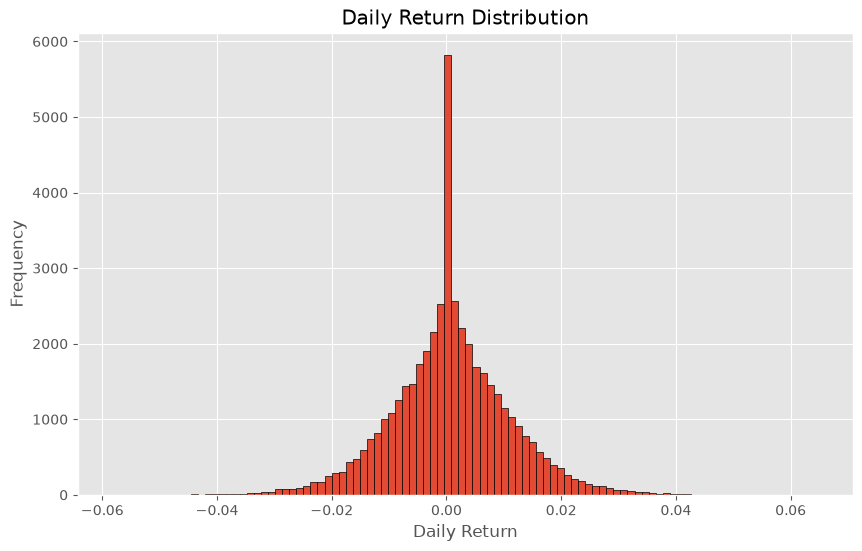

In [80]:
plt.figure(figsize=(10,6))

nav['daily_return'].dropna().hist(
    bins=100,
    edgecolor='black'
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig(
    "../charts/daily_return_distribution.png"
)

plt.show()

### CAGR Function

In [81]:
def calculate_cagr(group, years):

    trading_days = years * 252

    if len(group) < trading_days:
        return np.nan

    start_nav = group.iloc[-trading_days]['nav']
    end_nav = group.iloc[-1]['nav']

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

    return cagr

### Sharp Ratio

In [82]:
RF = 0.065
daily_rf = RF / 252

In [83]:
sharpe_data = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    sharpe = (

        (returns.mean() - daily_rf)

        /

        returns.std()

    ) * np.sqrt(252)

    sharpe_data.append({

        'amfi_code': code,
        'Sharpe_Ratio': sharpe

    })

sharpe_df = pd.DataFrame(sharpe_data)

### Sortino Ratio

In [84]:
sortino_data = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    downside = returns[
        returns < 0
    ]

    if len(downside) < 10:
        continue

    downside_std = downside.std()

    sortino = (

        (returns.mean() - daily_rf)

        /

        downside_std

    ) * np.sqrt(252)

    sortino_data.append({

        'amfi_code': code,
        'Sortino_Ratio': sortino

    })

sortino_df = pd.DataFrame(sortino_data)

### Nifty 100 Returns

In [85]:
nifty100 = benchmark[
    benchmark['index_name']
    == 'Nifty 100'
].copy()

In [86]:

# Convert dates to same format
nav['date'] = pd.to_datetime(nav['date']).dt.normalize()
benchmark['date'] = pd.to_datetime(benchmark['date']).dt.normalize()

# Extract NIFTY100 benchmark
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

# Sort by date
nifty100 = nifty100.sort_values('date')

# Calculate daily benchmark returns
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

print("NIFTY100 Shape:", nifty100.shape)
print(nifty100.head())

NIFTY100 Shape: (1150, 4)
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


### Alpha & Beta

In [87]:
from scipy.stats import linregress

alpha_beta = []

for code, group in nav.groupby('amfi_code'):

    # Merge fund returns with benchmark returns
    merged = pd.merge(
        group,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    # Remove missing values
    merged = merged.dropna()

    # Skip if insufficient data
    if len(merged) < 30:
        print(f"Skipping {code}: only {len(merged)} observations")
        continue

    # Linear regression
    result = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_beta.append({
        'amfi_code': code,
        'Alpha': result.intercept * 252,   # Annualized alpha
        'Beta': result.slope
    })

# Create DataFrame with fixed columns
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=['amfi_code', 'Alpha', 'Beta']
)

print("\nAlpha-Beta DataFrame:")
print(alpha_beta_df.head())
print("\nShape:", alpha_beta_df.shape)

# Save output
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)


Alpha-Beta DataFrame:
   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289

Shape: (40, 3)


### Maximum Drawdown

In [88]:
drawdown_data = []

for code, group in nav.groupby('amfi_code'):

    group = group.sort_values('date')

    running_max = group['nav'].cummax()

    drawdown = (

        group['nav']

        /

        running_max

        - 1

    )

    max_dd = drawdown.min()

    end_idx = drawdown.idxmin()

    end_date = group.loc[
        end_idx,
        'date'
    ]

    drawdown_data.append({

        'amfi_code': code,

        'Max_Drawdown':
        max_dd,

        'Worst_Date':
        end_date

    })

drawdown_df = pd.DataFrame(
    drawdown_data
)

### Merging all Matrices

In [108]:
# Ensure same datatype everywhere
dfs = [
    cagr_df,
    sharpe_df,
    sortino_df,
    alpha_beta_df,
    drawdown_df
]

for df in dfs:
    df['amfi_code'] = df['amfi_code'].astype(int)


# Merge step by step
scorecard = pd.merge(
    cagr_df,
    sharpe_df,
    on='amfi_code',
    how='inner'
)

scorecard = pd.merge(
    scorecard,
    sortino_df,
    on='amfi_code',
    how='inner'
)

scorecard = pd.merge(
    scorecard,
    alpha_beta_df,
    on='amfi_code',
    how='inner'
)

scorecard = pd.merge(
    scorecard,
    drawdown_df,
    on='amfi_code',
    how='inner'
)

print(scorecard.shape)
scorecard.head()

(40, 10)


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Max_Drawdown,Worst_Date
0,100016,-0.033055,-0.000316,NaN,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,2022-09-15
1,100025,0.025018,0.046143,NaN,-0.567095,-0.941821,0.042818,0.001158,-0.043083,2023-07-28
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,-0.162172,2022-05-12
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,-0.112916,2023-07-05
4,101207,-0.242421,-0.026965,NaN,0.162661,0.276644,0.108971,-0.065289,-0.354469,2026-05-11


### Adding Expense Ratio

In [90]:
scorecard = scorecard.merge(

    fund_master[
        ['amfi_code',
         'expense_ratio_pct',
         'scheme_name']
    ],

    on='amfi_code'
)

### Rankings

In [91]:
scorecard['return_rank'] = (

    scorecard['CAGR_3Y']

    .rank(pct=True)

)

In [92]:
scorecard['sharpe_rank'] = (

    scorecard['Sharpe_Ratio']

    .rank(pct=True)

)

In [93]:
scorecard['alpha_rank'] = (

    scorecard['Alpha']

    .rank(pct=True)

)

Inverse Expense Ratio

In [94]:
scorecard['expense_rank'] = (

    (-scorecard['expense_ratio_pct'])

    .rank(pct=True)

)

Inverse Drawdown

In [95]:
scorecard['dd_rank'] = (

    (-scorecard['Max_Drawdown'])

    .rank(pct=True)

)

### Fund Score(0-100)

In [96]:
scorecard['Fund_Score'] = (

    30
    * scorecard['return_rank']

    +

    25
    * scorecard['sharpe_rank']

    +

    20
    * scorecard['alpha_rank']

    +

    15
    * scorecard['expense_rank']

    +

    10
    * scorecard['dd_rank']

)

Normaize

In [97]:
scorecard['Fund_Score'] = (

    scorecard['Fund_Score']

    /

    scorecard['Fund_Score'].max()

) * 100

Save

In [98]:
scorecard = scorecard.sort_values(
    'Fund_Score',
    ascending=False
)

scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,Max_Drawdown,Worst_Date,expense_ratio_pct,scheme_name,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,Fund_Score
25,120505,0.303534,0.302065,NaN,1.180101,2.029353,0.292636,0.000549,-0.181885,2025-01-23,1.36,ICICI Pru Midcap Fund - Regular - Growth,0.900,0.900,0.950,0.65,0.625,100.000000
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,-0.162172,2022-05-12,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.975,0.850,0.875,0.60,0.500,97.041420
16,119094,0.309182,0.360660,NaN,0.998231,1.703797,0.260767,-0.066265,-0.209609,2022-08-11,1.38,Axis Midcap Fund - Regular - Growth,1.000,0.750,0.800,0.60,0.700,95.562130
21,119598,0.845322,0.278144,NaN,0.945308,1.675317,0.303370,-0.023196,-0.287060,2025-05-14,1.43,SBI Small Cap Fund - Regular Plan - Growth,0.850,0.675,1.000,0.50,0.900,93.343195
34,148567,0.145807,0.312786,NaN,1.448291,2.385644,0.269838,0.023684,-0.112657,2023-10-20,1.46,Mirae Asset Large Cap Fund - Regular - Growth,0.925,1.000,0.850,0.45,0.200,92.899408


### Top 5 Funds

In [99]:
top5 = scorecard.head(5)['amfi_code']
print(top5)

25    120505
2     100033
16    119094
21    119598
34    148567
Name: amfi_code, dtype: int64


### Nifty 50

In [100]:
# nifty50 = benchmark[
#     benchmark['index_name']
#     == 'Nifty 50'
# ].copy()
nifty50 = benchmark[
    benchmark['index_name']
    == 'NIFTY50'
].copy()

print(nifty50.shape)

(1150, 3)


### Benchmark Comparison Plot

In [101]:
plt.figure(figsize=(14,8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

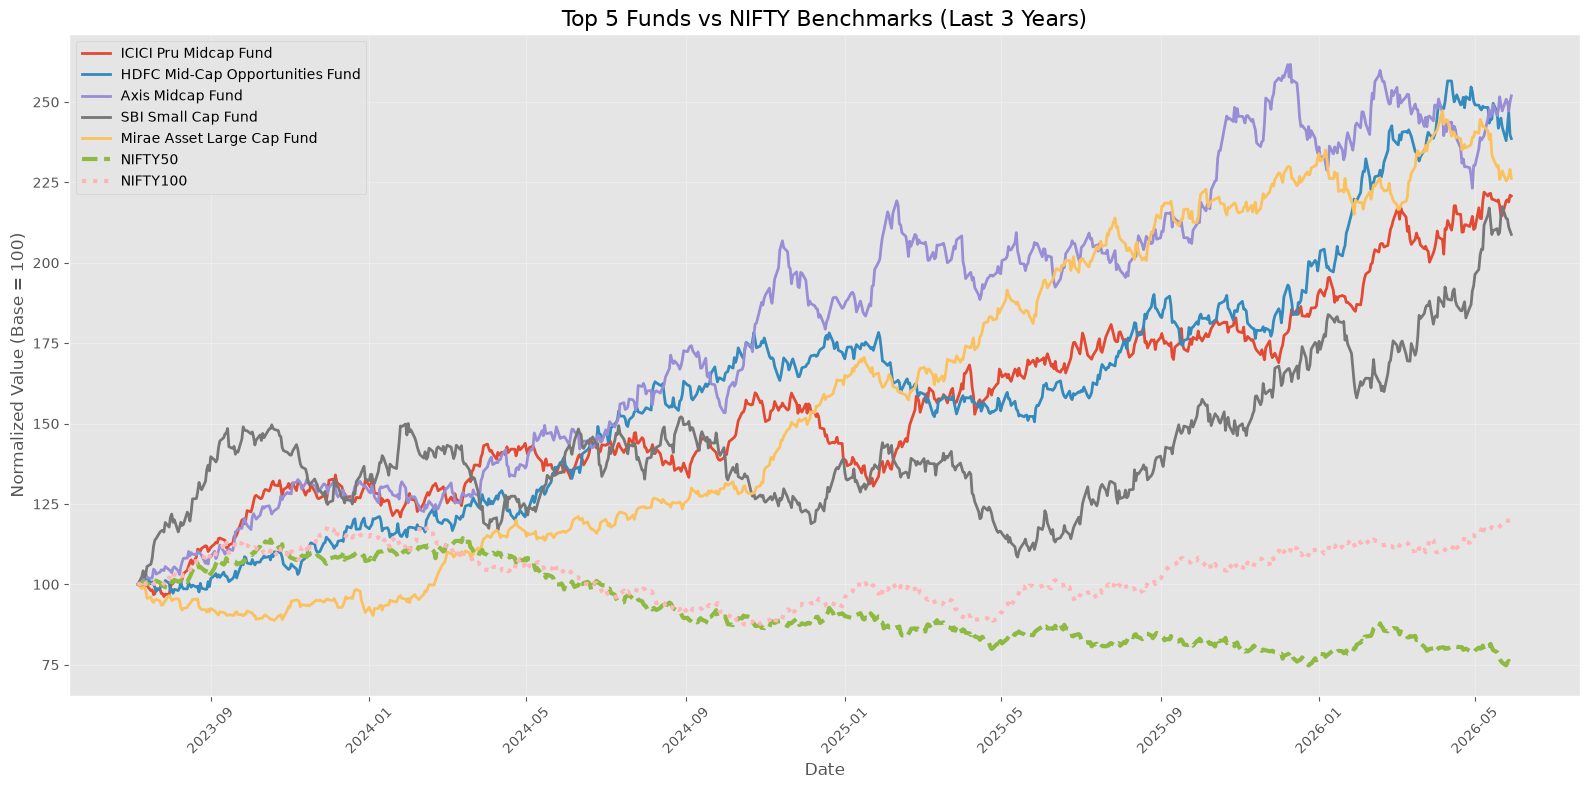

In [102]:
# ==============================
# Top 5 Funds vs NIFTY Benchmarks
# ==============================

import matplotlib.pyplot as plt
import pandas as pd

# Ensure date columns are datetime
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Get Top 5 funds from scorecard
top5 = scorecard.head(5)['amfi_code'].tolist()

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# -----------------------------
# Plot Top 5 Funds
# -----------------------------
for code in top5:

    temp = nav[
        nav['amfi_code'] == code
    ].copy()

    if temp.empty:
        print(f"Skipping {code}: No NAV data")
        continue

    temp = temp.sort_values('date')

    # Last 3 years (or all available if less)
    temp = temp.tail(min(756, len(temp)))

    if len(temp) < 2:
        print(f"Skipping {code}: Not enough data")
        continue

    temp['normalized'] = (
        temp['nav']
        / temp['nav'].iloc[0]
    ) * 100

    # Clean scheme name for legend
    scheme_name = scorecard.loc[
        scorecard['amfi_code'] == code,
        'scheme_name'
    ].iloc[0]

    scheme_name = (
        scheme_name
        .replace(" - Regular - Growth", "")
        .replace(" - Regular Plan - Growth", "")
    )

    ax.plot(
        temp['date'],
        temp['normalized'],
        linewidth=2,
        label=scheme_name
    )

# -----------------------------
# Plot NIFTY50
# -----------------------------
nifty50_plot = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

if not nifty50_plot.empty:

    nifty50_plot = nifty50_plot.sort_values('date')
    nifty50_plot = nifty50_plot.tail(min(756, len(nifty50_plot)))

    nifty50_plot['normalized'] = (
        nifty50_plot['close_value']
        / nifty50_plot['close_value'].iloc[0]
    ) * 100

    ax.plot(
        nifty50_plot['date'],
        nifty50_plot['normalized'],
        linewidth=3,
        linestyle='--',
        label='NIFTY50'
    )

# -----------------------------
# Plot NIFTY100
# -----------------------------
nifty100_plot = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

if not nifty100_plot.empty:

    nifty100_plot = nifty100_plot.sort_values('date')
    nifty100_plot = nifty100_plot.tail(min(756, len(nifty100_plot)))

    nifty100_plot['normalized'] = (
        nifty100_plot['close_value']
        / nifty100_plot['close_value'].iloc[0]
    ) * 100

    ax.plot(
        nifty100_plot['date'],
        nifty100_plot['normalized'],
        linewidth=3,
        linestyle=':',
        label='NIFTY100'
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    "Top 5 Funds vs NIFTY Benchmarks (Last 3 Years)",
    fontsize=16
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Value (Base = 100)", fontsize=12)

ax.legend(
    loc='upper left',
    fontsize=10
)

ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig(
    "../charts/top5_vs_benchmark.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Tracking Error

In [103]:
tracking_error = []

In [104]:
for code in top5:

    fund = nav[
        nav['amfi_code']
        == code
    ]

    merged = pd.merge(

        fund,

        nifty100[
            ['date',
             'benchmark_return']
        ],

        on='date'
    )

    merged = merged.dropna()

    te = (

        (

            merged['daily_return']

            -

            merged[
                'benchmark_return'
            ]

        ).std()

    ) * np.sqrt(252)

    tracking_error.append({

        'amfi_code': code,

        'Tracking_Error':
        te

    })

In [105]:
tracking_error_df = pd.DataFrame(
    tracking_error
)

tracking_error_df

,amfi_code,Tracking_Error
0,120505,0.231968
1,100033,0.228699
2,119094,0.237652
3,119598,0.283881
4,148567,0.189664
